Nom : KARBOUN Ahmed Master : GLCC

In [30]:
# ============================================================
# OBJECTIF DU CODE
# ============================================================
#
# Ce code construit un modèle de régression logistique from scratch.
#
# Il sert à prédire si un étudiant réussit (1) ou échoue (0)
# à partir de plusieurs caractéristiques (features).
#
# Le modèle commence par normaliser les données
# pour que toutes les variables soient sur la même échelle.
#
# Ensuite, il calcule une combinaison linéaire :
#      z = XW + b
#
# Puis applique la fonction sigmoïde pour obtenir une probabilité.
#
# L’entraînement utilise la descente de gradient
# pour minimiser la log-loss (negative log-likelihood).
#
# À la fin, le modèle peut prédire une classe
# et donner une probabilité de réussite.
#
# ============================================================

In [31]:


import numpy as np
import matplotlib.pyplot as plt


# DONNÉES

#  ----------------------------------------------------------
#  | Étudiant | F1 | F2 | F3 | F4 | F5 | F6 |
#  ----------------------------------------------------------
#  |    1     |  2 |  5 |  8 | 20 |  0 |  6 |
#  |    2     |  4 |  6 |  6 | 40 |  2 |  5 |
#  |    3     |  6 |  7 |  5 | 60 |  3 |  4 |
#  |    4     |  8 |  7 |  4 | 80 |  4 |  3 |
#  |    5     | 10 |  8 |  3 | 90 |  5 |  2 |
#  |    6     |  3 |  4 |  9 | 30 |  0 |  7 |
#  |    7     |  7 |  6 |  5 | 70 |  3 |  4 |
#  ----------------------------------------------------------
#
#  Interprétation possible :
#
#      F1 = heures d'étude
#      F2 = participation
#      F3 = exercices rendus
#      F4 = score de contrôle
#      F5 = absences
#      F6 = projets réalisés


In [32]:

X = np.array([        # la matrice des caractéristiques (features)

    [2,5,8,20,0,6],   # Étudiant 1
    [4,6,6,40,2,5],   # Étudiant 2
    [6,7,5,60,3,4],   # Étudiant 3
    [8,7,4,80,4,3],   # Étudiant 4
    [10,8,3,90,5,2],  # Étudiant 5
    [3,4,9,30,0,7],   # Étudiant 6
    [7,6,5,70,3,4]    # Étudiant 7

])


notes = np.array([10,13,15,17,18.5,11,16]) # les notes finales (target)

Classes :
[1 1 1 1 1 1 1]
Iteration 0 | Loss = 0.6931
Iteration 200 | Loss = 0.0535
Iteration 400 | Loss = 0.0263
Iteration 600 | Loss = 0.0174
Iteration 800 | Loss = 0.0129
Iteration 1000 | Loss = 0.0103
Iteration 1200 | Loss = 0.0086
Iteration 1400 | Loss = 0.0073

Probabilités :
[0.99320792 0.99320792 0.99320792 0.99320792 0.99320792 0.99320792
 0.99320792]

Classes prédites :
[1 1 1 1 1 1 1]


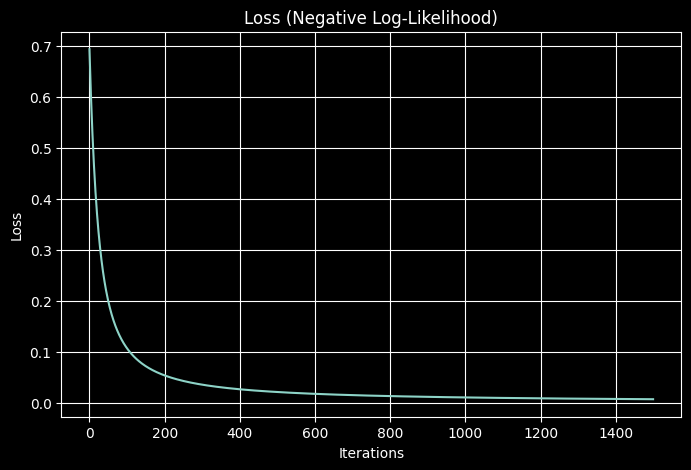

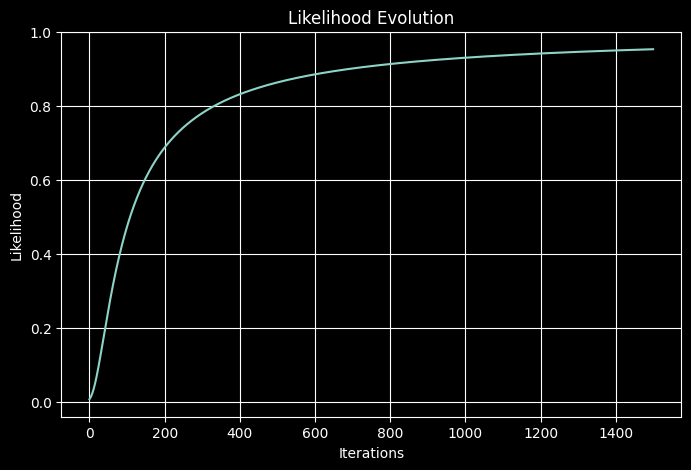

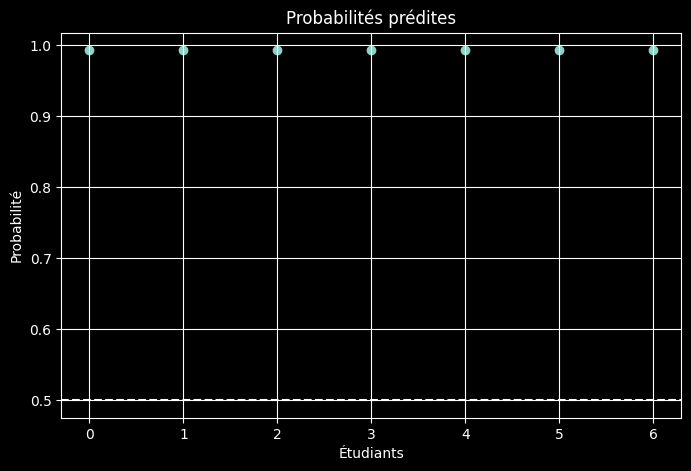

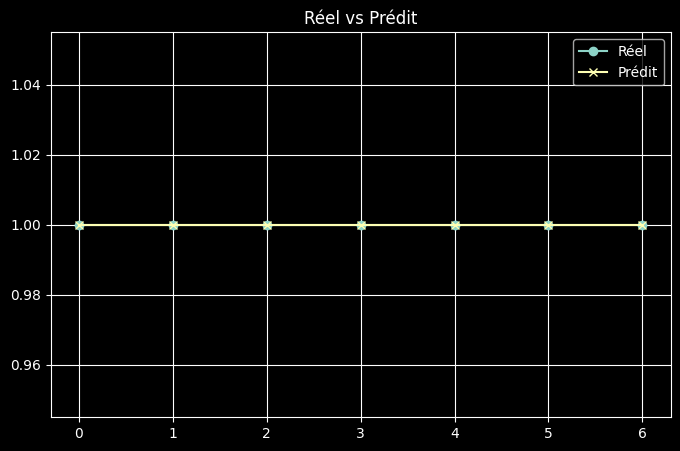

In [29]:

# Conversion en classes binaires
# y = 1 -> réussite
# y = 0 -> échec

y = (notes >= 10).astype(int) # ici, tous les étudiants ont réussi, donc y = [1, 1, 1, 1, 1, 1, 1]

print("Classes :")
print(y)


# 2) NORMALISATION
# Formule :           x_norm = (x - μ) / σ

X_mean = np.mean(X, axis=0) # μ
X_std = np.std(X, axis=0)   # σ

X = (X - X_mean) / X_std  # normalisation


# 3) FONCTION SIGMOID
#                   1
#      σ(z) = -------------
#               1 + e^(-z)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# 4) INITIALISATION

m, n = X.shape

W = np.zeros(n)
b = 0

lr = 0.1
epochs = 1500

loss_history = []
likelihood_history = []


# 5) ENTRAÎNEMENT

for i in range(epochs):

    z = np.dot(X, W) + b
    y_pred = sigmoid(z)

    # LIKELIHOOD (probabilité totale du dataset)
    # L = Π [ ŷ^y * (1 - ŷ)^(1-y) ]
    #
    # on multiplie toutes les probabilités

    likelihood = np.prod(
        (y_pred ** y) *
        ((1 - y_pred) ** (1 - y))
    )

    likelihood_history.append(likelihood)

    # LOG-LIKELIHOOD
    # log(L) = Σ [ y log(ŷ) + (1-y) log(1-ŷ) ]
    log_likelihood = np.sum(
        y * np.log(y_pred + 1e-9)
        +
        (1 - y) * np.log(1 - y_pred + 1e-9)
    )

    # NEGATIVE LOG-LIKELIHOOD = LOSS
    # Loss = -log(L)

    loss = -np.mean(
        y * np.log(y_pred + 1e-9)
        +
        (1 - y) * np.log(1 - y_pred + 1e-9)
    )

    loss_history.append(loss)

  # GRADIENTS (dérivées de -log likelihood)

    dw = np.dot(X.T, (y_pred - y)) / m
    db = np.mean(y_pred - y)

    # GRADIENT DESCENT
    # on minimise -log(L)
    # donc on maximise likelihood

    W = W - lr * dw # mise à jour des poids
    b = b - lr * db # mise à jour du biais

    if i % 200 == 0:
        print(f"Iteration {i} | Loss = {loss:.4f}")


# 6) PRÉDICTION

def predict(X_input):

    X_scaled = (X_input - X_mean) / X_std

    z = np.dot(X_scaled, W) + b
    proba = sigmoid(z)

    prediction = (proba >= 0.5).astype(int)

    return prediction, proba


# 7) TEST

classes_predites, probas = predict(X * X_std + X_mean)

print("\n==============================")
print("Probabilités :")
print(probas)

print("\nClasses prédites :")
print(classes_predites)


# 8) VISUALISATION

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.title("Loss (Negative Log-Likelihood)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(likelihood_history)
plt.title("Likelihood Evolution")
plt.xlabel("Iterations")
plt.ylabel("Likelihood")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.scatter(range(len(probas)), probas)
plt.axhline(y=0.5, linestyle='--')
plt.title("Probabilités prédites")
plt.xlabel("Étudiants")
plt.ylabel("Probabilité")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(y, marker='o', label="Réel")
plt.plot(classes_predites, marker='x', label="Prédit")
plt.legend()
plt.title("Réel vs Prédit")
plt.grid(True)
plt.show()


# ============================================================
# RÉSUMÉ MATHÉMATIQUE
# ============================================================
#
#      X
#      ↓
#   z = XW + b
#      ↓
#   ŷ = sigmoid(z)
#      ↓
#   Likelihood
#      ↓
#   log(Likelihood)
#      ↓
#   -log(Likelihood) = Loss
#      ↓
#   Gradient Descent
#      ↓
#   mise à jour W, b
#
# ============================================================